In this exploration, we will try to model the S&P 500 using the GBM, Merton Jump-Diffusion and ARCH Models.

Below we download the timeseries and see how the volatility estimates compare.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.special import factorial
from statsmodels.graphics.tsaplots import plot_acf

# Set aesthetic plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
from statsmodels.tsa.stattools import acf

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from time_series.realised_vol import close_to_close_vol, yang_zhang_vol, garman_klass_vol
from time_series.simulators import fit_garch_mle, fit_merton_mle, simulate_garch, simulate_gbm, simulate_merton_jump
from time_series.stylized_facts import test_stylized_facts

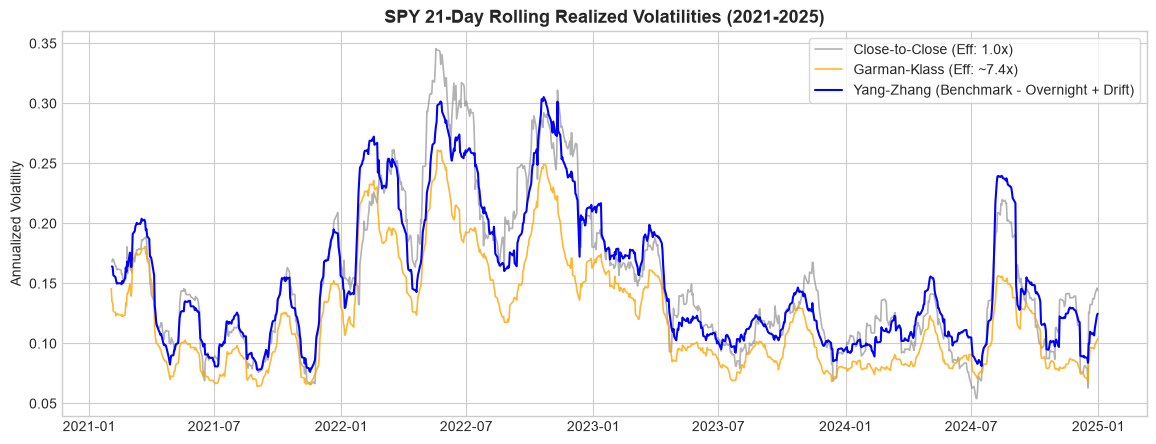

--- Realized Volatility Summary (Latest 21-day Annualized) ---
Close-to-Close : 0.1442
Garman-Klass   : 0.1040
Yang-Zhang     : 0.1248


In [2]:
# 1. Download real market data (SPY)
ticker = "SPY"
df = yf.download(ticker, start="2021-01-01", end="2025-01-01", progress=False)

# Clean multi-index columns if returned by yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df['CC_Vol'] = close_to_close_vol(df, window=21)
df['GK_Vol'] = garman_klass_vol(df, window=21)
df['YZ_Vol'] = yang_zhang_vol(df, window=21)

# Plot Realized Volatilities
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['CC_Vol'], label='Close-to-Close (Eff: 1.0x)', alpha=0.6, color='gray', lw=1.2)
ax.plot(df.index, df['GK_Vol'], label='Garman-Klass (Eff: ~7.4x)', alpha=0.8, color='orange', lw=1.2)
ax.plot(df.index, df['YZ_Vol'], label='Yang-Zhang (Benchmark - Overnight + Drift)', color='blue', lw=1.5)

ax.set_title(f"{ticker} 21-Day Rolling Realized Volatilities (2021-2025)", fontsize=13, fontweight='bold')
ax.set_ylabel("Annualized Volatility")
ax.legend(loc='upper right', frameon=True)
plt.show()

print("--- Realized Volatility Summary (Latest 21-day Annualized) ---")
print(f"Close-to-Close : {df['CC_Vol'].iloc[-1]:.4f}")
print(f"Garman-Klass   : {df['GK_Vol'].iloc[-1]:.4f}")
print(f"Yang-Zhang     : {df['YZ_Vol'].iloc[-1]:.4f}")


## Model Calibration

##### A. Geometric Brownian Motion (GBM)
GBM parameters $(\mu, \sigma)$ are calibrated directly from empirical time series:
- **Drift ($\mu$):** $\hat{\mu} = \bar{r}_{\text{daily}} \times 252$
- **Diffusion Volatility ($\sigma$):** Set $\hat{\sigma} = \sigma_{YZ}$ (Yang-Zhang annualized volatility) over a rolling window (e.g., 21 trading days) to utilize intraday OHLC efficiency rather than the noisier sample standard deviation.

##### B. Merton Jump-Diffusion (MJD) Calibration via MLE
MJD has five parameters $\mathbf{\Theta} = (\mu, \sigma, \lambda, \mu_J, \sigma_J)$. Over discrete daily steps $\Delta t = 1/252$, the return density is a Poisson mixture of Gaussians.

Conditional on $j$ jumps occurring during $\Delta t$:

$$r_t \mid j \sim \mathcal{N}\left(\mu_j, \sigma_j^2\right)$$

Where:
- $\mu_j = \left(\mu - \lambda k - \frac{1}{2}\sigma^2\right)\Delta t + j \mu_J$
- $\sigma_j^2 = \sigma^2 \Delta t + j \sigma_J^2$
- $k = \exp\left(\mu_J + \frac{1}{2}\sigma_J^2\right) - 1$ (Compensator drift)

The total log-likelihood over sample size $T$, truncating jump summation at $N_{\text{max}} = 10$:

$$\ln \mathcal{L}(\mathbf{\Theta}) = \sum_{t=1}^T \ln \left( \sum_{j=0}^{N_{\text{max}}} \frac{e^{-\lambda \Delta t}(\lambda \Delta t)^j}{j!} \frac{1}{\sqrt{2\pi \sigma_j^2}} \exp\left( -\frac{(r_t - \mu_j)^2}{2\sigma_j^2} \right) \right)$$

Parameters $\mathbf{\Theta}^* = \arg\max \ln \mathcal{L}(\mathbf{\Theta})$ are obtained using bounded quasi-Newton numerical optimization (L-BFGS-B).

##### C. GARCH(1,1) Calibration via MLE
Parameters $(\mu, \omega, \alpha, \beta)$ are estimated by maximizing the Gaussian log-likelihood conditioned on the recursive variance path:

$$\ln \mathcal{L}(\mu, \omega, \alpha, \beta) = -\frac{1}{2}\sum_{t=1}^T \left( \ln(2\pi) + \ln(\sigma_t^2) + \frac{(r_t - \mu)^2}{\sigma_t^2} \right)$$

$$\sigma_t^2 = \omega + \alpha (r_{t-1} - \mu)^2 + \beta \sigma_{t-1}^2$$



In [3]:
# Extract clean daily log returns
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
log_returns = df['Log_Ret'].dropna().values
dt = 1 / 252

# 1. Stylized Facts Verification
facts = test_stylized_facts(log_returns)
print("="*60)
print(f" EMPIRICAL STYLIZED FACTS ANALYSIS: {ticker}")
print("="*60)
print(f"Sample Size (Days)           : {facts['sample_size']}")
print(f"Annualized Return Mean       : {facts['mean_daily']*252:.2%}")
print(f"Annualized Sample Std        : {facts['annualized_vol']:.2%}")
print(f"Sample Skewness              : {facts['skewness']:.4f}")
print(f"Excess Kurtosis              : {facts['excess_kurtosis']:.4f} (Fat-Tailed: {facts['is_fat_tailed']})")
print(f"Jarque-Bera p-value          : {facts['jarque_bera']['p_value']:.4e} (Normality Rejected: {facts['jarque_bera']['normal_rejected']})")
print(f"Raw Return Autocorr p-value  : {facts['raw_returns_autocorr']['p_value']:.4f} (White Noise: {not facts['raw_returns_autocorr']['is_serially_correlated']})")
print(f"Squared Return Autocorr p-val: {facts['volatility_clustering']['p_value']:.4e} (Clustering: {facts['volatility_clustering']['has_clustering']})")
print(f"Leverage Effect Correlation  : {facts['leverage_effect_correlation']:.4f}")

# 2. Calibrate GARCH(1,1)
garch_params = fit_garch_mle(log_returns)
print("\n" + "="*60)
print(" CALIBRATED GARCH(1,1) PARAMETERS")
print("="*60)
for k, v in garch_params.items():
    print(f"{k:12s}: {v:.6f}")

# 3. Calibrate Merton Jump-Diffusion
merton_params = fit_merton_mle(log_returns, dt=dt)
print("\n" + "="*60)
print(" CALIBRATED MERTON JUMP-DIFFUSION PARAMETERS")
print("="*60)
for k, v in merton_params.items():
    print(f"{k:26s}: {v:.6f}")


 EMPIRICAL STYLIZED FACTS ANALYSIS: SPY
Sample Size (Days)           : 1004
Annualized Return Mean       : 13.06%
Annualized Sample Std        : 16.49%
Sample Skewness              : -0.2664
Excess Kurtosis              : 1.9325 (Fat-Tailed: True)
Jarque-Bera p-value          : 3.1360e-37 (Normality Rejected: True)
Raw Return Autocorr p-value  : 0.3788 (White Noise: True)
Squared Return Autocorr p-val: 2.6551e-44 (Clustering: True)
Leverage Effect Correlation  : -0.0577

 CALIBRATED GARCH(1,1) PARAMETERS
mu          : 0.000809
omega       : 0.000004
alpha       : 0.079977
beta        : 0.879744
half_life   : 16.859443

 CALIBRATED MERTON JUMP-DIFFUSION PARAMETERS
mu                        : 0.155190
sigma                     : 0.142878
lambda                    : 15.000000
mu_J                      : -0.008242
sigma_J                   : 0.018680
implied_total_annual_vol  : 0.163300


### Quantitative Framework for Model Evaluation & Validation

To evaluate the predictive and structural validity of calibrated models against actual market data, we employ a three-tier validation battery:

##### Tier 1: Residual Diagnostics (In-Sample Goodness-of-Fit)
Extract standardized model residuals:

$$z_t = \frac{r_t - \hat{\mu}}{\hat{\sigma}_t}$$

- **ARCH Filter Test:** Run the Ljung-Box test on squared residuals $z_t^2$. If the volatility model is correctly specified, $p > 0.05$ (residuals behave as pure white noise with no remaining ARCH effects).
- **Normality of Standardized Residuals:** Run the Jarque-Bera test on $z_t$. Standardized residuals should move significantly closer to Gaussianity than raw returns.

##### Tier 2: Distributional Metric & Tail Matching (Monte Carlo Validation)
Simulate $M = 1,000$ paths of length $T$ and evaluate:
- **Moment Convergence:** Compare empirical skewness and excess kurtosis with the distribution of simulated moments:
  
  $$\kappa_{\text{excess, empirical}} \stackrel{?}{\approx} \frac{1}{M}\sum_{m=1}^M \kappa_{\text{excess, simulated}}^{(m)}$$

- **Two-Sample Kolmogorov-Smirnov (KS) Test:**
  
  $$D_{KS} = \sup_x |F_{\text{empirical}}(x) - F_{\text{simulated}}(x)|$$
  
  A higher $p$-value indicates superior empirical cumulative distribution function (CDF) alignment.

##### Tier 3: Non-Linear Dependence & Autocorrelation Matching
- Plot the empirical Autocorrelation Function (ACF) of squared returns $\rho_{r^2}(\tau)$ against the ACF of simulated squared returns.
- **Criterion:** GARCH simulated paths should mirror the slow empirical power/exponential decay, whereas GBM and Merton paths will immediately drop into the zero noise band.


--- STATISTICAL VALIDATION TABLE ---
                Model Daily Mean Daily Vol Skewness Excess Kurtosis KS-Test p-val vs SPY
        Empirical SPY   0.000518    0.0104   -0.266           1.933                  N/A
        Simulated GBM   0.000488    0.0079   -0.006          -0.008               0.0177
Simulated Merton Jump   0.000545    0.0103   -0.525           2.890               0.1305
 Simulated GARCH(1,1)   0.000807    0.0093   -0.009           0.500               0.2941


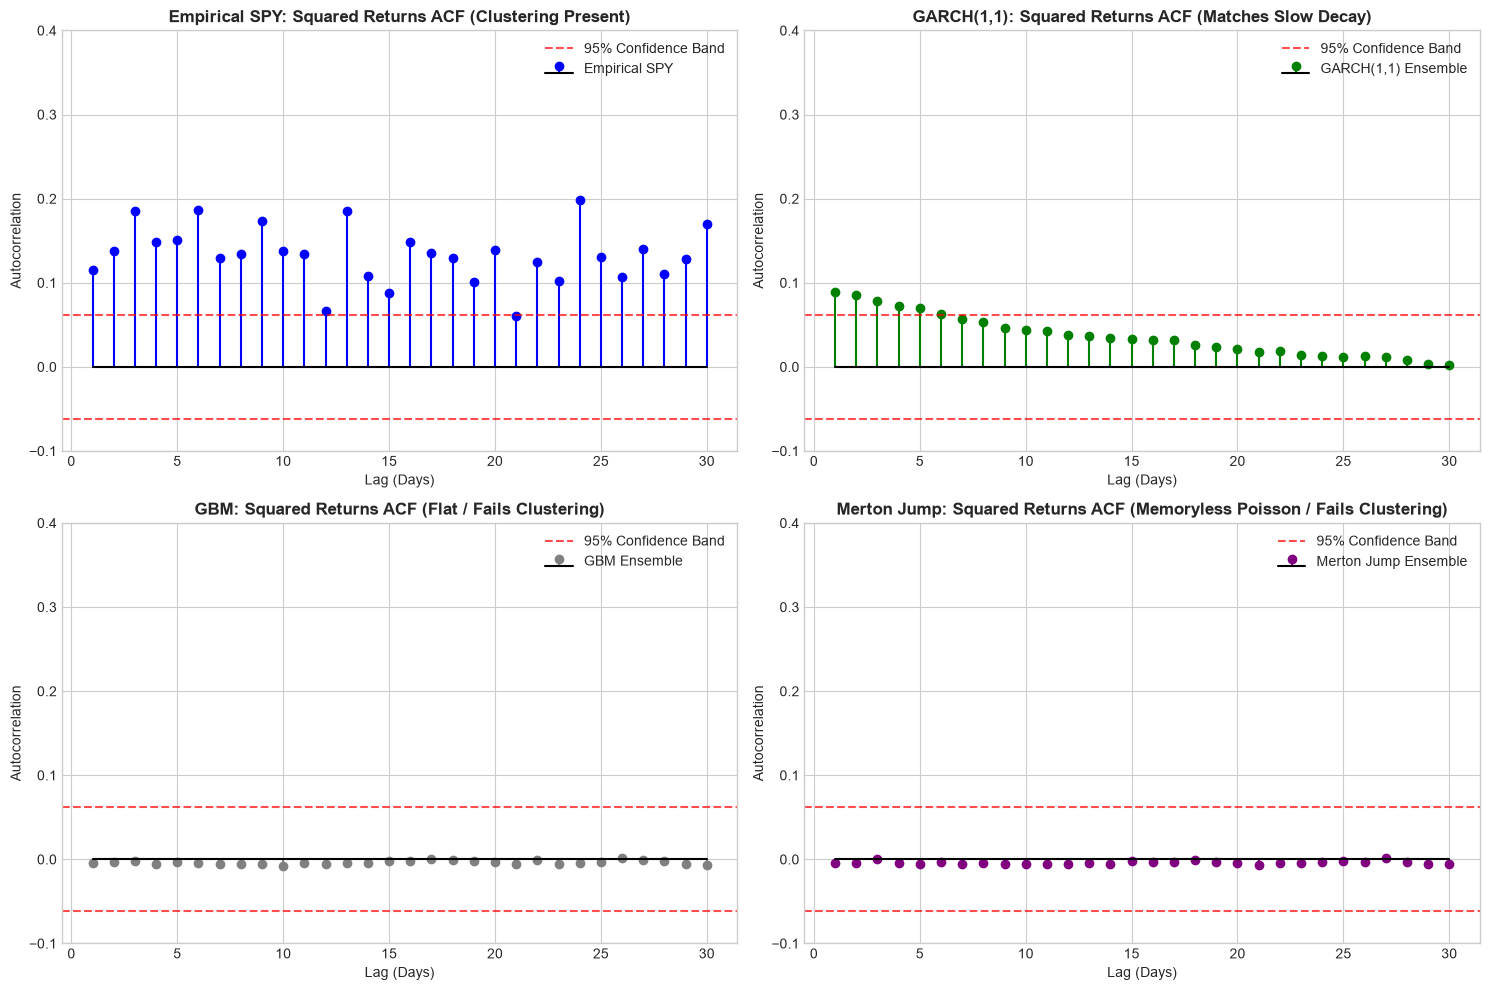

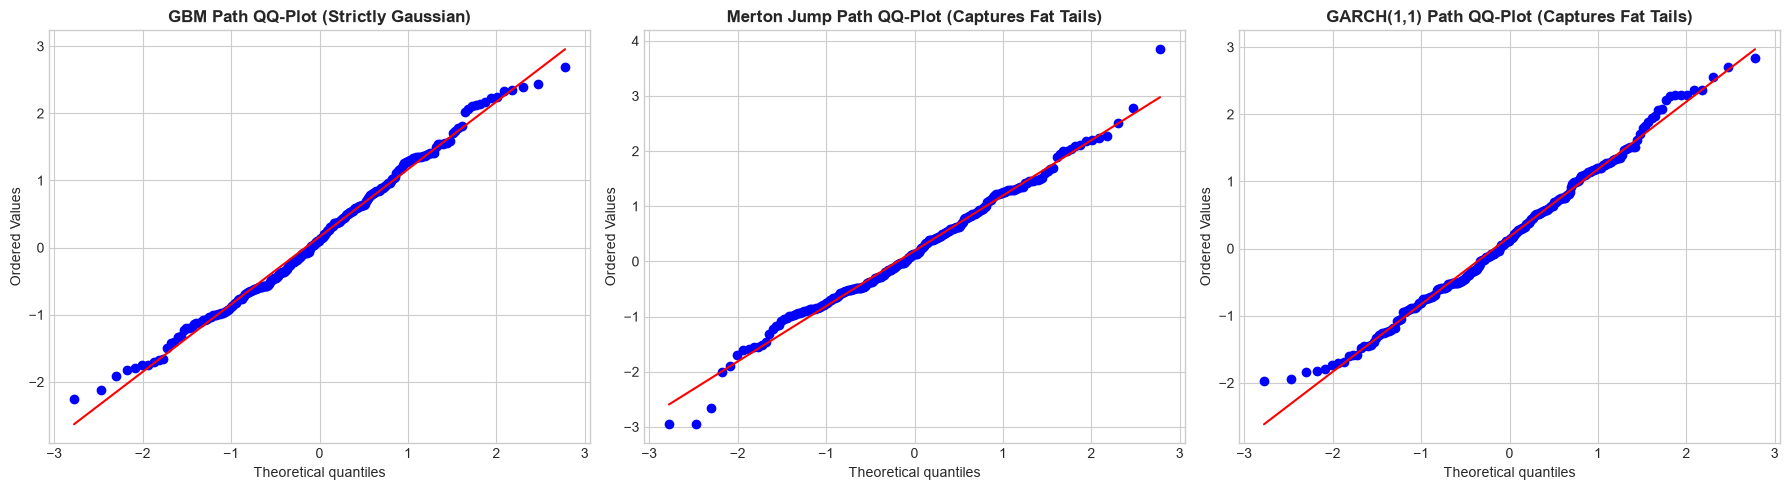

In [4]:
S0 = float(df['Close'].iloc[-1])
T_sim = 1.0
N_steps = 252
N_paths = 1000

# 1. GBM Simulation (Parameterized with Yang-Zhang realized vol)
sigma_yz = float(df['YZ_Vol'].dropna().iloc[-1])
gbm_paths = simulate_gbm(
    S0=S0, 
    mu=facts['mean_daily'] * 252, 
    sigma=sigma_yz, 
    T=T_sim, 
    dt=dt, 
    n_paths=N_paths
)

# 2. Merton Jump Simulation
merton_paths = simulate_merton_jump(
    S0=S0,
    mu=merton_params['mu'],
    sigma=merton_params['sigma'],
    lam=merton_params['lambda'],
    mu_J=merton_params['mu_J'],
    sigma_J=merton_params['sigma_J'],
    T=T_sim,
    dt=dt,
    n_paths=N_paths
)

# 3. GARCH(1,1) Simulation
garch_rets, garch_vars = simulate_garch(
    omega=garch_params['omega'],
    alpha=garch_params['alpha'],
    beta=garch_params['beta'],
    mu=garch_params['mu'],
    n_steps=N_steps,
    n_paths=N_paths
)

# Extract flattened returns for statistical comparison
gbm_rets_mat = np.diff(np.log(gbm_paths), axis=0)
merton_rets_mat = np.diff(np.log(merton_paths), axis=0)
garch_rets_mat = garch_rets

# Extract flattened returns for statistical comparison
gbm_sim_rets = gbm_rets_mat.flatten()
merton_sim_rets = merton_rets_mat.flatten()
garch_sim_rets = garch_rets_mat.flatten()


# =====================================================================
# 4. Statistical Validation & Diagnostic Battery
# =====================================================================

def evaluate_distribution_moments(r: np.ndarray, name: str) -> dict:
    return {
        "Model": name,
        "Daily Mean": f"{np.mean(r):.6f}",
        "Daily Vol": f"{np.std(r, ddof=1):.4f}",
        "Skewness": f"{stats.skew(r):.3f}",
        "Excess Kurtosis": f"{stats.kurtosis(r, fisher=True):.3f}",
        "KS-Test p-val vs SPY": f"{stats.ks_2samp(r, log_returns).pvalue:.4f}" if name != "Empirical SPY" else "N/A"
    }

validation_table = pd.DataFrame([
    evaluate_distribution_moments(log_returns, "Empirical SPY"),
    evaluate_distribution_moments(gbm_sim_rets, "Simulated GBM"),
    evaluate_distribution_moments(merton_sim_rets, "Simulated Merton Jump"),
    evaluate_distribution_moments(garch_sim_rets, "Simulated GARCH(1,1)")
])

print("--- STATISTICAL VALIDATION TABLE ---")
print(validation_table.to_string(index=False))

max_lags = 30

def compute_ensemble_squared_acf(rets_matrix: np.ndarray, nlags: int = 30) -> np.ndarray:
    """
    Computes the ACF of squared returns for each individual path (along time)
    and returns the ensemble average across all paths.
    rets_matrix shape: (n_steps, n_paths)
    """
    n_steps, n_sim_paths = rets_matrix.shape
    acf_matrix = np.zeros((nlags + 1, n_sim_paths))
    
    for i in range(n_sim_paths):
        path_sq = (rets_matrix[:, i] - np.mean(rets_matrix[:, i]))**2
        acf_matrix[:, i] = acf(path_sq, nlags=nlags, fft=True)
        
    return np.mean(acf_matrix, axis=1)



# Compute ensemble ACFs
empirical_sq_acf = acf((log_returns - np.mean(log_returns))**2, nlags=max_lags, fft=True)
garch_sq_acf = compute_ensemble_squared_acf(garch_rets_mat, nlags=max_lags)
merton_sq_acf = compute_ensemble_squared_acf(merton_rets_mat, nlags=max_lags)
gbm_sq_acf = compute_ensemble_squared_acf(gbm_rets_mat, nlags=max_lags)

# =====================================================================
# 5. Diagnostic Plots: Corrected ACF & QQ Comparison
# =====================================================================

lags = np.arange(max_lags + 1)
conf_bound = 1.96 / np.sqrt(len(log_returns))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Empirical vs GARCH (Volatility Clustering)
axes[0, 0].stem(lags[1:], empirical_sq_acf[1:], linefmt='b-', markerfmt='bo', basefmt='k-', label='Empirical SPY')
axes[0, 0].axhline(conf_bound, color='red', linestyle='--', alpha=0.7, label='95% Confidence Band')
axes[0, 0].axhline(-conf_bound, color='red', linestyle='--', alpha=0.7)
axes[0, 0].set_title("Empirical SPY: Squared Returns ACF (Clustering Present)", fontweight='bold')
axes[0, 0].set_xlabel("Lag (Days)")
axes[0, 0].set_ylabel("Autocorrelation")
axes[0, 0].set_ylim(-0.1, 0.4)
axes[0, 0].legend()

axes[0, 1].stem(lags[1:], garch_sq_acf[1:], linefmt='g-', markerfmt='go', basefmt='k-', label='GARCH(1,1) Ensemble')
axes[0, 1].axhline(conf_bound, color='red', linestyle='--', alpha=0.7, label='95% Confidence Band')
axes[0, 1].axhline(-conf_bound, color='red', linestyle='--', alpha=0.7)
axes[0, 1].set_title("GARCH(1,1): Squared Returns ACF (Matches Slow Decay)", fontweight='bold')
axes[0, 1].set_xlabel("Lag (Days)")
axes[0, 1].set_ylabel("Autocorrelation")
axes[0, 1].set_ylim(-0.1, 0.4)
axes[0, 1].legend()

# 2. GBM vs Merton (Fails Volatility Clustering)
axes[1, 0].stem(lags[1:], gbm_sq_acf[1:], linefmt='gray', markerfmt='o', basefmt='k-', label='GBM Ensemble')
axes[1, 0].axhline(conf_bound, color='red', linestyle='--', alpha=0.7, label='95% Confidence Band')
axes[1, 0].axhline(-conf_bound, color='red', linestyle='--', alpha=0.7)
axes[1, 0].set_title("GBM: Squared Returns ACF (Flat / Fails Clustering)", fontweight='bold')
axes[1, 0].set_xlabel("Lag (Days)")
axes[1, 0].set_ylabel("Autocorrelation")
axes[1, 0].set_ylim(-0.1, 0.4)
axes[1, 0].legend()

axes[1, 1].stem(lags[1:], merton_sq_acf[1:], linefmt='purple', markerfmt='o', basefmt='k-', label='Merton Jump Ensemble')
axes[1, 1].axhline(conf_bound, color='red', linestyle='--', alpha=0.7, label='95% Confidence Band')
axes[1, 1].axhline(-conf_bound, color='red', linestyle='--', alpha=0.7)
axes[1, 1].set_title("Merton Jump: Squared Returns ACF (Memoryless Poisson / Fails Clustering)", fontweight='bold')
axes[1, 1].set_xlabel("Lag (Days)")
axes[1, 1].set_ylabel("Autocorrelation")
axes[1, 1].set_ylim(-0.1, 0.4)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# =====================================================================
# 6. QQ-Plots of Standardized Residuals
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use representative single paths for QQ visual clarity
stats.probplot(gbm_rets_mat[:, 0] / np.std(gbm_rets_mat[:, 0]), dist="norm", plot=axes[0])
axes[0].set_title("GBM Path QQ-Plot (Strictly Gaussian)", fontweight='bold')

stats.probplot(merton_rets_mat[:, 0] / np.std(merton_rets_mat[:, 0]), dist="norm", plot=axes[1])
axes[1].set_title("Merton Jump Path QQ-Plot (Captures Fat Tails)", fontweight='bold')

stats.probplot(garch_rets_mat[:, 0] / np.std(garch_rets_mat[:, 0]), dist="norm", plot=axes[2])
axes[2].set_title("GARCH(1,1) Path QQ-Plot (Captures Fat Tails)", fontweight='bold')

plt.tight_layout()
plt.show()
